In [ ]:
GROQ_API_KEY=""
API_KEY="tvly-dev-16bXhi-"

In [ ]:
!pip install langchain deepagents langchain-groq tavily-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.4/297.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.8/72.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 726.3/726.3 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 44.6 MB/s eta 0:00:00
  Attempting uninstall: langsmith
    Found existing installation: langsmith 0.10.2
    Uninstalling langsmith-0.10.2:
      Successfully uninstalled langsmith-0.10.2
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.4.9
    Uninstalling langchain

In [ ]:
!
!pip install tavily-python
from tavily import TavilyClient

In [ ]:
client=TavilyClient(api_key=API_KEY)
from typing import Literal
from langchain_core.tools import tool
@tool
def web_search(query:str,max_result:int=3):
    """
    Performs a web search using the TavilyClient.

    Args:
        query (str): The search query.
        max_result (int): The maximum number of search results to return. Defaults to 3.
    """
    return client.search(query,max_result)

Create a DeepAgent


In [ ]:
from deepagents import create_deep_agent
from langchain_groq import ChatGroq

model = ChatGroq(model_name="llama-3.3-70b-versatile", groq_api_key=GROQ_API_KEY)

In [ ]:
#from langchain_core.tools import StructuredTool

agent=create_deep_agent(
    model=model,
    tools=[web_search],
    system_prompt="Act as Master in Research"
)

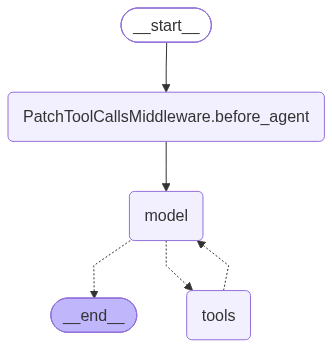

In [ ]:
agent

In [ ]:
res=agent.invoke({"messages":[{"role":"user","content":"What is Langgraph"}]})
print(res)

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=web_search{"query": "Langgraph", "max_result": 5}</function>'}}